# Searching for the category

For this code along we are only going to use the products DataFrame. However, if you believe there is information in other tables that can help to create categories, please feel free to explore.

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
# products_qu.csv
url = "https://drive.google.com/file/d/1butZ9T3Kgy8ZNsuRi80X-5pd3zjF554I/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_qu = pd.read_csv(path)

# orderlines_qu.csv
url = "https://drive.google.com/file/d/1nOfZA34PkdA2snnmWf4zMFW468a7yT4C/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qu = pd.read_csv(path)

In [ ]:
products_qu

,sku,name,desc,price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364
...,...,...,...,...,...,...
9987,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horiz...,29.99,1,12282
9988,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartment...,69.95,1,1392
9989,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartment...,69.95,1,1392
9990,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartment...,69.95,0,1392


In [ ]:
products_qu['brand'] = products_qu['sku'].str[:3]
products_qu

,sku,name,desc,price,in_stock,type,brand
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,RAI
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,APP
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,APP
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,APP
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,KIN
...,...,...,...,...,...,...,...
9987,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horiz...,29.99,1,12282,BEL
9988,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartment...,69.95,1,1392,THU
9989,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartment...,69.95,1,1392,THU
9990,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartment...,69.95,0,1392,THU


In [ ]:
product_category_df = products_qu.copy()

In [ ]:
product_category_df.head()

,sku,name,desc,price,in_stock,type,brand
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,RAI
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,APP
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,APP
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,APP
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,KIN


## 1.&nbsp; Category creation by search term
Let's start by creating a column `category`. For now we'll fill this column with a blank string `""`.

In [ ]:
product_category_df["category"] = ""
product_category_df.head()

,sku,name,desc,price,in_stock,type,brand,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,RAI,
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,APP,
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,APP,
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,APP,
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,KIN,


We can find all the products with certain words in their `description` using `.loc[]` and `.str.contains()`. Here we'll look at all the items that have the word `keyboard` in their description.

Next, we change the value in the category column to `keyboard` for all of these keyboard products.

## 2.&nbsp; Category creation using regex
We can also use a product's `name` to select products for our categories.

Now let's look at how this can help us in our category creation.

First, we'll reset all the values in the category column to an empty string `""`.

Creating 13 different categories

1.	Smartphones -
2.	Laptops
3.	Tablet -
4.	Networking -
5.	Wearables -
6.	Camera-drones
7.	Storage & Memory -
8.	Accessories -
9.	Software -
10.	Smart_homes -
11. desktop_professional_hardware
12. tv-monitors
13. others




In [ ]:
#   smartphone
product_category_df.loc[
     (
       (product_category_df["name"].str.contains(
        r"iphone|galaxy|huawei|xiaomi|pixel|smartphone|Apple iPhone|Open - Apple iPhone |Like new - Apple iPhone ",
         case=False, na=False)
       | product_category_df["type"].astype(str).isin(['24821716', '51601716', '85641716', '24811716', '85651716','1716', '21571716', '21561716', '113291716', '113281716', '113271716'])
        )
      & (product_category_df["price"] > 400)
       )
 & ~product_category_df["type"].astype(str).isin([
      "11865403","11905404","1216","11935397","12215397","1229","1230","1231",     "12635403","12645406","1296","13005399","1325","13555403","13615399", "13855401","1424","1433","14365395","1515","21485407","5384","5395","5398", "5399","5403","5405","5407","5720","1,44E+11","5,49E+11","24215399", "12285400","9094"]),
     "category"
   ] = "smartphone"


In [ ]:
#  laptop
product_category_df.loc[(
      (
       product_category_df["name"].str.contains(
       r"laptop|notebook|macbook|thinkpad|ideapad|chromebook|MobileStudio Pro|Cintiq Companion|Apple MacBook Pro 15 ",
       case=False, na=False)
      | product_category_df["type"].astype(str).isin(["1,02E+12", "9,29E+11", '5,39E+11', "2,17E+11",'51902158'])
      )
        & (product_category_df["price"] > 1000)
      )
       & ~ product_category_df["type"].astype(str).isin(["1392","11935397","13005399","13835403","14305406", "54085407", "13855401",'12355400',"20642062", "13835403","13835403", "1325", "8696", "10230", "57445397", "5403", "12585395", "10142", "1229", "12995397","12755395", "1433", "12215397","12655397", "1515", "1231", '1405']),
      "category"
  ] = "laptop"

In [ ]:
#   tablet
product_category_df.loc[
    (
    (product_category_df["name"].str.contains(
        r"ipad|tablet|galaxy tab|surface|Graphics Tablet|Wacom Cintiq|Apple iPad Pro |Apple iPad Wi-Fi",
        case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1405", "106431714"])
    )
    & (product_category_df["price"] >=239)
    )
    &  ~product_category_df["type"].astype(str).isin(["1,44E+11", "12085400", "8696","14035403", "1216", "21535407", "5720", "12635403", "13835403", "1392", "1229", "13005399", "12575403", "10230", "101781405", "14305406", "12645406", "20642062", "54085407", "54025401" ,"13005399", "13855401", "13955395", "5403", "12285400", "13615399", '14365395', "11865403", "12051714"]),
    "category"
] = "tablet"


In [ ]:
# networking
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"router|wifi|modem|network|ethernet|dLAN|switch|adapter|D-Link|satellite|TP-Link|Airport|video recorder", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1334", "1325"])
    )
    & (~product_category_df["name"].astype(str).str.contains(r"\b(?:case|cable)\b",case=False, na=False)
)
    &  ~product_category_df["type"].astype(str).isin(["106431714", "1404", "24215399"]),
   "category"
] = "networking"


In [ ]:
# wearable
product_category_df.loc[(
    (
    product_category_df["name"].str.contains(r"watch|smartwatch|fitbit|wearable|Apple Nike Sport|apple watch|galaxy watch|watch series|Steel Watch|virtual reality glasses|Apple Watch Series 2Fitbit|Jawbone|MyKronoz|Nokia Intelligent Activity|Pebble Smartwatch|iHealth|Withings Activite", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["24895185", "2449", "24885185", "5185"])
    )
    & (product_category_df["price"] >=129)
    )
     &  ~product_category_df["type"].astype(str).isin(["1515",'5405', '2449', "12282", "12285400", "2434", "24215399", '2425','11865403','13615399','12645406','12285400', '5384']),
    "category"
] = "wearable"

In [ ]:
# audio
product_category_df.loc[(
    (
    product_category_df["name"].str.contains(r"headphone|earphone|earbuds|airpods|speaker|speakers|headset|iPod|audio|Beats|IK Multimedia|Blue Microphones|IK Multimedia iRig", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["5384","5398","1375"])
     )
    & (product_category_df["price"] >15)
    )
    &  ~product_category_df["type"].astype(str).isin(["1,44E+11", "12051714", "5405", "1515", "5720","1216", "14305406", "12645406", "12285400", "13615399", "1296", "21485407"]),
    "category"
] = "audio"

In [ ]:
# camera_drone
product_category_df.loc[(
    (
    product_category_df["name"].str.contains(r"GoPro Hero|dslr|mirrorless|gopro|drone|dji|mavic|parrot|Parrot Drone|Mavic Pro|Kaiser Baas", case=False, na=False)

    )
      & (product_category_df["price"] >=89)
    )
    &  ~product_category_df["type"].astype(str).isin(["112355400", "5398"]),
    "category"
] = "camera_drone"

In [ ]:
# storage & memory.
#
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"\bssd\b|\bhdd\b|usb|raid|g-speed|g-technology|pegasus|5big|qnap|nas|drobo|iscsi|san|wd my cloud| hard drive|hard disc|flash drive|memory|sd card|WD|Seagate|SDHC|microSD|promise|My Book Pro|OWC|Express|Western Digital|Wacom Intuos|Kingston V300|anti-theft system|Enlargement Kit|EVO|Synology RackStation|SanDisk|Kingston|Crucial|OWC Aura SSD kits|Lacie d2 Thunderbolt|Synology NAS Server DS| WD Hard Drive|FCM Mac Memory| iAdapt|Synology RX1217 expansion|Synology Pack DS416J|Transcend JetDrive Lite ", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["11935397","12585395", "12655397","12755395","12995397","12215397","1280", "1276", "12175397","57445397", "1433", "1364", "42945397"])
    )
    &  ~product_category_df["type"].astype(str).isin(["1,02E+12", "5,39E+11", "2,16E+11", "9,29E+11", "13955395","14305406", "14365395", "15435404", "1282", "21632158", "1405", "1325", "1230", "5398", "1387", "118692158", "2,17E+11","1375","1,44E+11", "1334", "24895185"]),
    "category"
] =  "storage & memory"


In [ ]:
## accessory
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"case|cover|charger|cable|keyboard|stand|hub|correa|stylus|power bank|logitech mouse|usb mouse|powerstation|bracelet|belt|pointer|LaCie|powerCube|Wacom Bamboo|battery|Wacom Intuos|Crucial|kit|Minibatt|Belkin cable|\bcase\b|\bcover\b|\bcable\b|\bcharger\b|\badapter\b|\bkeyboard\b|\bmouse\b|\bstand\b|\bhub\| b\bram\b|memory|dimm|so-dimm|ddr3|ddr4|ecc|Screen Protector|Leather Folio|Housing|Apple Pencil|iPhone Folio|Support Kukaclip car|Belkin Car Charger|Logitech|iOttie Easy|Zagg |Twelve South|Startech|SecurityXtra|MIXIT Belkin Car Charge|Tucano tugo|Leather|Thule|OWC In-line Digital Temperature|Synology Rail Kit|Sliding Rail|SwitchEasy iPhone Case|Tempered glass|Protector InvisiGlass|protector|I AM Cardboard|Mujjo Single-Layered|Muvit|NewerTech NuTouch|Olloclip 4-in-1|Polaroid ZINK|Prynt|Utopia Retrak 360 card|ZIP Polaroid Mobile| Classic Belkin|Griffin Survivor|Mediterrans cover|Twelve South|Speck SeeThru|Urban Armor Gear| Adonith| Air Protect SheerForce|Be.ez|Wacom Intuos|Waterproof| Moshi| Satechi|Speck ", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["11865403", "12635403", "13835403", "13835403", "8696", "14035403", "1515", "13615299", "1335", "1229", "13555403","12355400", "13955395", "14365395", "1216", "12585395", "12645403", "5395", "5405", "5403","1230", "1387","10142", "10230", "5720", "13855401", "12085400","1392", "13005399","1325", "2425", "54864259", "12755395", "2449","5399","1405", "1424", "13615399", "24215399", "12282", "5384", "9094", "12285400"])
    )
    &  ~product_category_df["type"].astype(str).isin(["1,02E+12", "24895185", "1282", "12215397", "11935397" ,"1364","9,29E+11", "24885185", "1433", "12995397", "12655397","1276", "1334", "1405","42945397","5185", "5398", "57445397","1,44E+11", "4259", "14305406","15435404","21485407","54085407", "12645406","NaN"]),
    "category"
] = "accessory"

In [ ]:
# software
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"software|license|subscription|antivirus|office 365|AppleCare|edition|quarkxpress|office|adobe", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1416"])
    )
    &  ~product_category_df["type"].astype(str).isin(["11935397","1405","11905404","11865403","1229","1298", "2449","5399", "12175397","12995397"
  ]),
    "category"
] = "software"


In [ ]:
# smart_home
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"smart home|alexa|google home|echo|nest|sensor|smart bulb|smart plug|philips hue|scale|ThermoPeanut|GuardPeanut| Withings Home|Ninebot by Segway", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["9094"])
    )
    &  ~product_category_df["type"].astype(str).isin(["15435404", "1276", "21485407"]),
    "category"
] = "smart_home"


In [ ]:
#  desktop_professional_hardware"
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"apple iMac|apple imac pro|apple mac pro|apple mac mini|workstation|Synology RX1217RP|Docking Station|Griffin Multidock ", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1282", "5,74E+15", "1,02E+12", "2158", "2,16E+11", "21632158"])
    )
    & ~product_category_df["type"].astype(str).isin(["12755395", "1280", "8696", "11935397", "12175397", "12655397", "12995397", "1276","1334", "12585395"]),
    "category"
] = "desktop_professional_hardware"


In [ ]:
#   tv_monitor
product_category_df.loc[(
    (
    product_category_df["name"].str.contains(r"tv|television|monitor|screen|dell|display|LED Monitor|LCD Monitor|Open - Dell|Open - LG", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1296", "113464259", "4259"])
    )
       & (product_category_df["price"] >= 100)
    )
    &  ~product_category_df["type"].astype(str).isin(["113464259", "11865403", "1216","12355400", "13555403", "12085400", "12585395", "1405", "12175397", "1282", "12635403","12285400", "13005399", "1325", "14035403", "2425", "54864259", "5398", "8696", "9094", "1,44E+11", "1231", "12645406", "21485407", "13835403", "1334", "4259", "5395"]),
    "category"
] = "tv_monitor"

In [ ]:
product_category_df.loc[product_category_df["category"] == "", "category"] += ", other"

In [ ]:
product_category_df["category"] = (
    product_category_df["category"]
    .fillna("other")
    .str.strip()
    .str.lower()
)

In [ ]:
product_category_df["category"].value_counts()


,count
category,
accessory,4062
storage & memory,2655
desktop_professional_hardware,1064
", other",541
audio,285
smartphone,261
tv_monitor,252
tablet,221
smart_home,174


Sample of 20 product_categories

In [ ]:
product_category_df.sample(20)

,sku,name,desc,price,in_stock,type,brand,category
510,PAC0491,Apple Mac Pro Quad-Core 37GHz | 32GB RAM | 1TB...,Apple Mac Pro Quad-Core 37GHz 32GB RAM and 1TB...,4769.00,0,1282,PAC,desktop_professional_hardware
4559,TRK0008,Bravo Gold Trackr Locator,Bluetooth locator objects APP for iPhone,29.99,0,11905404,TRK,", other"
1009,MUV0146,Muvit Clear Transparent Back Cover iPhone 6,"thin, transparent housing for iPhone 6.",9.99,0,11865403,MUV,accessory
2870,FCM0038-4,Mac memory FCM 32GB (4x8GB) SO-DIMM DDR3 1867MHz,Mac memory FCM 32GB (4x8GB) DDR3 1867MHz SO-DI...,607.92,0,1364,FCM,storage & memory
6400,WIT0035,Withings Steel HR 40 Black Clock,Smartwatch that records the heart rate and mov...,199.95,0,11905404,WIT,", other"
7829,WAC0236-A,Open - Education - A4 Wacom Bamboo Slate Gray,Smart Bloc notes A4 size reconditioned app inc...,149.99,0,1298,WAC,accessory
2826,APP1348,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 8GB ...",IMac desktop computer 27 inch 5K Retina i5 3.2...,3169.00,0,"5,74E+15",APP,desktop_professional_hardware
6411,MUJ0027,"Mujjo MacBook Pro sleeve Sleeve 13 ""/ Air 13"" ...",Travel Case for MacBook Pro 13-inch MacBook Ai...,69.90,1,13835403,MUJ,accessory
2654,PAC1046,"Apple iMac 27 ""Core i5 3.3GHz Retina 5K | 32GB...",IMac desktop computer 27 inch 5K Retina i5 3.3...,3589.00,0,"5,74E+15",PAC,desktop_professional_hardware
2493,IFX0037,Battery Kit complete change iFixit iPhone 3GS ...,Battery replacement kit with tools for iPhone ...,19.95,0,12645406,IFX,", other"


Total individual categories

In [ ]:
num_category = product_category_df['category'].nunique()
print('Number of individual categories:', num_category)

Number of individual categories: 14


How many products are labelled as Other

In [ ]:
other_count = (product_category_df['category'] == 'other').sum()
print("Number of products in 'Other':", other_count)

Number of products in 'Other': 0


Percentage of products classified as 'other'

In [ ]:
total_product = len(product_category_df)
other_count = (product_category_df['category'] == 'other').sum()
percent_other = (other_count / total_product)* 100
print(f"Percentage of 'Other' products: {percent_other:.2f}%")

Percentage of 'Other' products: 0.00%


Summary: In total i have 250 categories which represent 100% of products.

## Analysis

In [ ]:
# Merge orderlines_qu with product_category_df
prod_ol_df = orderlines_qu.merge(product_category_df, on='sku', how='left')

Get counts per category in descending order

In [ ]:
counts_series = prod_ol_df['category'].value_counts()

categories = counts_series.index.tolist()
values = counts_series.values.tolist()

# Convert to a clean DataFrame for easier analysis
counts_df = counts_series.reset_index()
counts_df.columns = ['category', 'count']
counts_df

,category,count
0,accessory,23967
1,storage & memory,15229
2,", other",3741
3,smartphone,2279
4,tv_monitor,1745
5,smart_home,1362
6,software,1170
7,audio,1049
8,tablet,1004
9,wearable,680


In [ ]:
# sns.catplot(kind='count',
#     data=counts_df,
#     y='category',
#     height=4,
#     aspect=2.5
# )

In [ ]:
# Calculate mean price per category
mean_price_by_category = prod_ol_df.groupby('category')['price'].mean().sort_values(ascending=False)
print(mean_price_by_category)

category
laptop                           1106.545631
desktop_professional_hardware     946.469043
smartphone                        618.378473
tablet                            584.657470
tv_monitor                        415.471937
wearable                          387.807971
camera_drone                      327.448603
audio                             194.539762
storage & memory                  194.005532
smart_home                        100.527144
software                           98.195239
networking                         93.663178
, other                            75.761246
accessory                          63.208729
Name: price, dtype: float64


Creating the revenue column
Price Category with total revenue

In [ ]:
prod_ol_df['revenue'] = prod_ol_df['unit_price'] * prod_ol_df['product_quantity']
prod_ol_df

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,category,revenue
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,smart_home,47.49
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720,IOT,accessory,18.99
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399,APP,accessory,72.19
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298,CRU,accessory,60.90
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404,PEB,wearable,142.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,9.99
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,19.98
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,19.98
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,29.97


Products by price category

In [ ]:
def price_category(price):
    if price < 50:
        return "Low Price"
    elif price < 200:
        return "Medium Price"
    elif price < 600:
        return "High Price"
    else:
        return "Premium"

# Adjusted for your products DataFrame
prod_ol_df["price_category"] = prod_ol_df["price"].apply(price_category)
prod_ol_df

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,category,revenue,price_category
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,smart_home,47.49,Medium Price
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720,IOT,accessory,18.99,Low Price
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399,APP,accessory,72.19,Medium Price
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298,CRU,accessory,60.90,Medium Price
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404,PEB,wearable,142.49,High Price
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,9.99,Low Price
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,19.98,Low Price
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,19.98,Low Price
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,29.97,Low Price


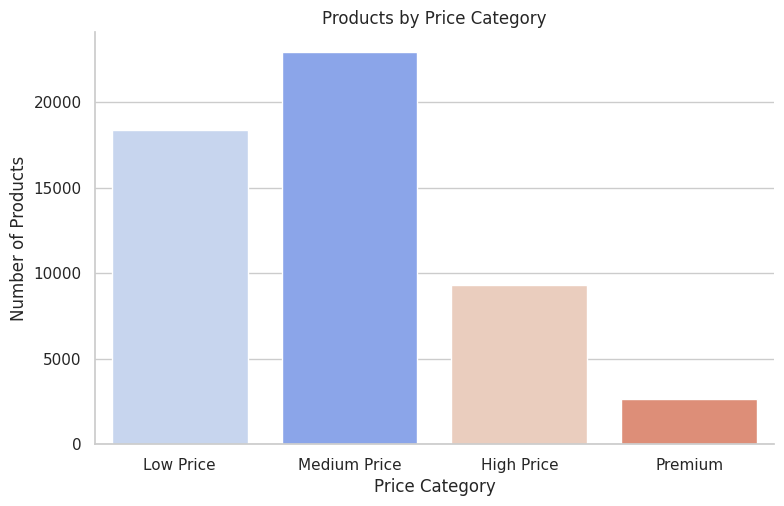

In [ ]:
#Set the theme globally
sns.set_theme(style="whitegrid")

# 2. Use catplot with kind='count'
# height and aspect replace plt.figure(figsize)
g = sns.catplot(
    data=prod_ol_df,
    x='price_category',
    kind='count',
    order=['Low Price', 'Medium Price', 'High Price', 'Premium'],
    palette='coolwarm',
    hue='price_category',
    height=5,
    aspect=1.6
)
g.set(title='Products by Price Category', xlabel= 'Price Category', ylabel='Number of Products')


Revenue by Price category

In [ ]:
# Calculate total revenue per price category (in millions)
revenue_price = (
    prod_ol_df.groupby('price_category')['revenue']
    .sum()
    .sort_values(ascending=False) / 1_000_000)

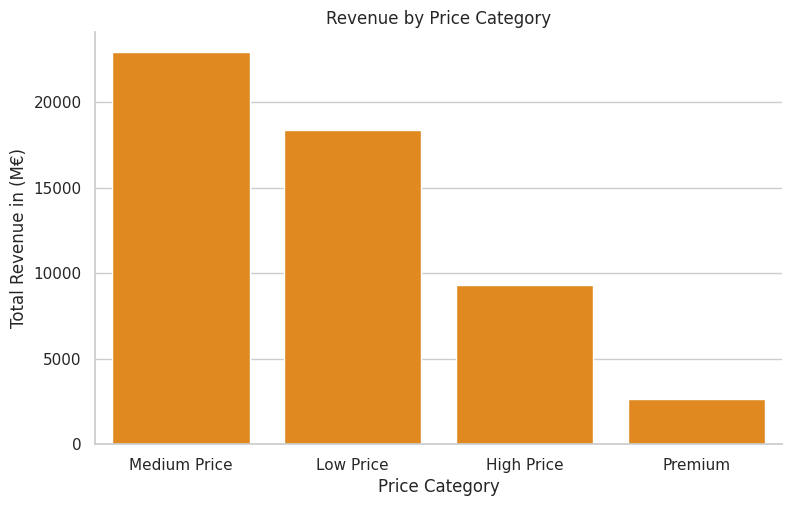

In [ ]:
ax = sns.catplot(
      data=prod_ol_df,
      x='price_category',
      kind='count',
      color='darkorange',
      height=5,
      aspect=1.6
  );
ax.set(title= 'Revenue by Price Category', xlabel='Price Category', ylabel='Total Revenue in (M€)')

Category of products that generate the most revenue

In [ ]:
# Sum revenue per category (in millions)
category_revenue = (
    prod_ol_df.groupby('category')['revenue']
    .sum()
    .reset_index()
    .sort_values('revenue', ascending=False)
)
category_revenue['revenue_million'] = category_revenue['revenue'] / 1_000_000

# Select top 30 categories for better visual clarity
top_30 = category_revenue.head(30).copy()
top_30['Category Group'] = 'Other'
top_30.loc[top_30.index[:10], 'Category Group'] = 'Top 10'

# Identify top 10 categories
top10 = category_revenue.head(10)['category']

# Add a highlight column
category_revenue['highlight'] = category_revenue['category'].apply(lambda x: 'Top 10' if x in top10.values else 'Other')


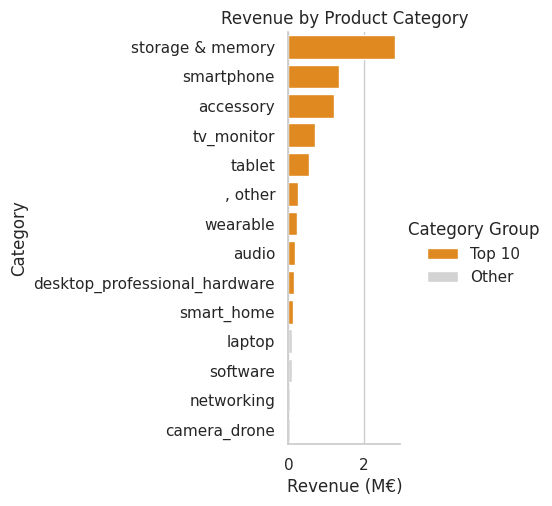

In [ ]:
ab =sns.catplot(
    data=top_30,
    x='revenue_million',
    y='category',
    hue='Category Group',
    kind='bar',
    palette={'Top 10': 'darkorange', 'Other': 'lightgray'},
    dodge=False,
    width=0.8
);
ab.set(title='Revenue by Product Category', xlabel='Revenue (M€)', ylabel='Category')


Discount strategy

In [ ]:
prod_ol_df["discount"] = prod_ol_df["price"] - prod_ol_df["unit_price"]


In [ ]:
prod_ol_df["discount_pct"] = (prod_ol_df["discount"] / prod_ol_df["price"]) * 100
prod_ol_df["discount_pct"] = prod_ol_df["discount_pct"].round(2)

In [ ]:
# Count discounted products
discounted_count = prod_ol_df[prod_ol_df["discount"] > 0].shape[0]
print(f"Number of discounted products: {discounted_count}")

Number of discounted products: 49404


The percentage of discounted products out of all products:

In [ ]:
total_products = prod_ol_df.shape[0]
discounted_pct = (discounted_count / total_products) * 100
print(f"Percentage of discounted products: {discounted_pct:.2f}%")

Percentage of discounted products: 92.81%


Summary: The analysis shows that 92.81% of products are discounted, indicating the absence of a clearly defined or effectively implemented discount strategy.

In [ ]:
# Group by SKU and check if any order line for that SKU was discounted
product_discounted = prod_ol_df.groupby('sku')['discount'].apply(lambda x: (x > 0).any())

# Count discounted and not discounted products
discount_counts = product_discounted.value_counts()

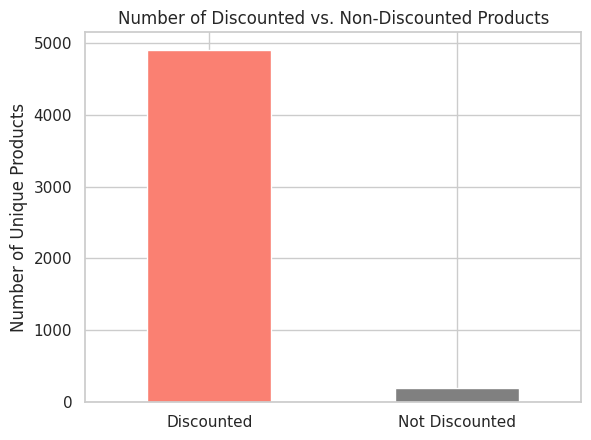

In [ ]:
import matplotlib.pyplot as plt
# Plot with discounted in red
colors = ['salmon' if discounted else 'gray' for discounted in discount_counts.index]

discount_counts.plot(kind='bar', color=colors)
plt.xticks([0, 1], ['Discounted', 'Not Discounted'], rotation=0)
plt.ylabel('Number of Unique Products')
plt.title('Number of Discounted vs. Non-Discounted Products')
plt.xlabel('')  # Remove x-axis label
plt.show()

What category is being the most discounted?

In [ ]:
# Calculate average discount percentage per category
avg_discount_by_category = (
    prod_ol_df.groupby('category')['discount_pct']
    .mean()
    .reset_index()
    .sort_values('discount_pct', ascending=False)
    .head(10)
)

print(avg_discount_by_category)

                         category  discount_pct
1                       accessory     27.620014
4   desktop_professional_hardware     26.604545
3                    camera_drone     26.157206
6                      networking     21.924740
9                        software     21.491906
2                           audio     20.779323
7                      smart_home     19.028686
12                     tv_monitor     18.201633
10               storage & memory     16.422071
0                         , other     15.578273


Text(0.5, 1.0, 'Top 10 Most Discounted Product Categories')

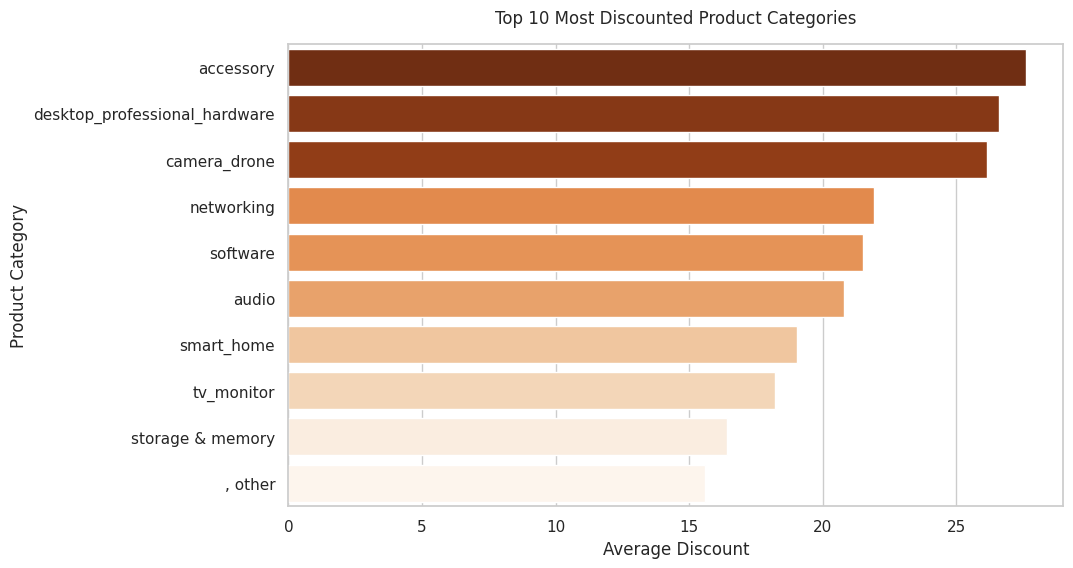

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=avg_discount_by_category,
    x='discount_pct',
    y='category',
    hue='discount_pct',
    palette='Oranges',
    legend=False
)

# Customizing labels and title
plt.xlabel('Average Discount')
plt.ylabel('Product Category')
plt.title('Top 10 Most Discounted Product Categories', pad=15)



In [ ]:
prod_ol_df

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand,category,revenue,price_category,discount,discount_pct
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,smart_home,47.49,Medium Price,13.50,22.13
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720,IOT,accessory,18.99,Low Price,3.96,17.25
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399,APP,accessory,72.19,Medium Price,16.81,18.89
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298,CRU,accessory,60.90,Medium Price,16.09,20.90
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404,PEB,wearable,142.49,High Price,157.50,52.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,9.99,Low Price,15.01,60.04
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,19.98,Low Price,15.01,60.04
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,19.98,Low Price,15.01,60.04
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,accessory,29.97,Low Price,15.01,60.04


Average Order Value: Discounted vs Full Price

In [ ]:
# Calculate total revenue per order and whether it had any discount
order_stats = prod_ol_df.groupby('id_order').agg({
    'revenue': 'sum',
    'discount': 'any'
})

# AOV for each group
aov_with_discount = order_stats[order_stats['discount'] == True]['revenue'].mean()
aov_no_discount = order_stats[order_stats['discount'] == False]['revenue'].mean()

difference = aov_with_discount - aov_no_discount
percentage_increase = (difference / aov_no_discount) * 100

print(f"AOV with discount:    €{aov_with_discount:.2f}")
print(f"AOV without discount: €{aov_no_discount:.2f}")
print(f"Difference:           €{difference:.2f} ({percentage_increase:.1f}% higher with discounts)")

AOV with discount:    €192.82
AOV without discount: €128.40
Difference:           €64.42 (50.2% higher with discounts)


Text(0.5, 1.0, 'Average Order Value: Discounted vs Full Price Orders')

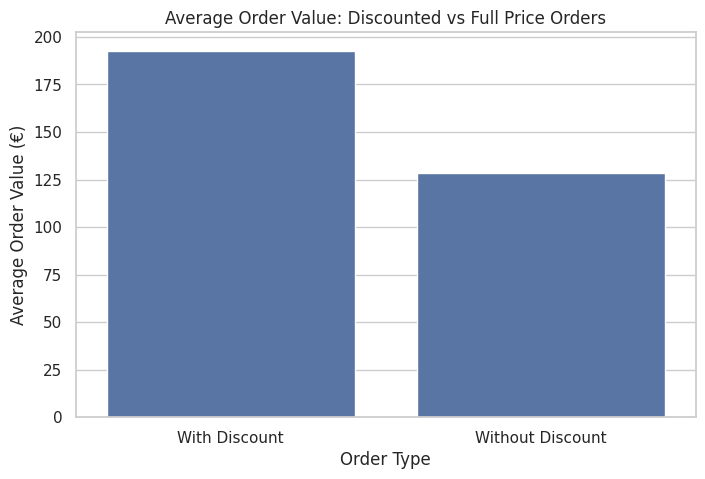

In [ ]:
aov_data = pd.DataFrame({
    'Order Type': ['With Discount', 'Without Discount'],
    'Average Order Value (€)': [aov_with_discount, aov_no_discount]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=aov_data, x='Order Type', y='Average Order Value (€)')
plt.title('Average Order Value: Discounted vs Full Price Orders')

## Seasonality — Black Friday Detail

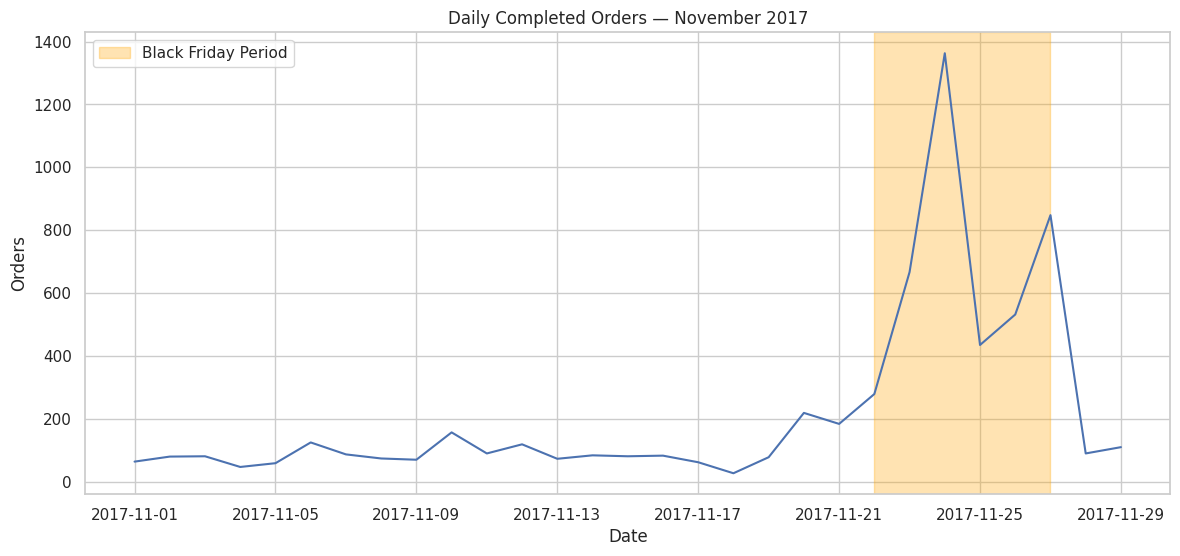

In [ ]:
# November 2017 detail with Black Friday highlighted
prod_ol_df['date'] = pd.to_datetime(prod_ol_df['date'])
mask = (
    (prod_ol_df['date'] >= '2017-11-01') &
    (prod_ol_df['date'] <= '2017-11-30')
)
november_data = prod_ol_df[mask]
daily_sales = november_data.resample('D', on='date')['id_order'].nunique().reset_index()
daily_sales.columns = ['date', 'orders']

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=daily_sales, x='date', y='orders', ax=ax)
ax.axvspan('2017-11-22', '2017-11-27', alpha=0.3, color='orange', label='Black Friday Period')

plt.title('Daily Completed Orders — November 2017')
plt.ylabel('Orders')
plt.xlabel('Date')
plt.legend()
plt.show()

In [ ]:
# Black Friday stats
november = prod_ol_df[
    (prod_ol_df['date'] >= '2017-11-01') &
    (prod_ol_df['date'] <= '2017-11-30')
]

bf_mask = november['date'].between('2017-11-21', '2017-11-27')
bf_avg = november[bf_mask].groupby(november[bf_mask]['date'].dt.date)['id_order'].nunique().mean()
normal_avg = november[~bf_mask].groupby(november[~bf_mask]['date'].dt.date)['id_order'].nunique().mean()
bf_max = november[bf_mask].groupby(november[bf_mask]['date'].dt.date)['id_order'].nunique().max()
multiplier = bf_avg / normal_avg

print(f"Normal November daily average: {normal_avg:.0f} orders")
print(f"Black Friday week daily average: {bf_avg:.0f} orders")
print(f"Black Friday peak (single day): {bf_max:.0f} orders")
print(f"Multiplier: {multiplier:.2f}x")

Normal November daily average: 122 orders
Black Friday week daily average: 577 orders
Black Friday peak (single day): 1363 orders
Multiplier: 4.72x
